
# Skin Cancer Detection using CNN (ResNet50)

This notebook implements a clean CNN pipeline for skin cancer classification using HAM10000 dataset.

Pipeline:
- Data Loading
- Preprocessing & Augmentation
- Train/Test Split (70:30)
- ResNet50 Model
- Training & Evaluation


In [1]:

import sys
!{sys.executable} -m pip install torch torchvision scikit-learn matplotlib seaborn tqdm



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: /opt/anaconda3/bin/python -m pip install --upgrade pip


In [3]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models

from sklearn.metrics import classification_report, confusion_matrix

from tqdm import tqdm


In [4]:

IMG_DIR = Path("Skin Cancer/Skin Cancer")
CSV_PATH = Path("HAM10000_metadata.csv")

df = pd.read_csv(CSV_PATH)
df.head()


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [7]:

label_map = {label: idx for idx, label in enumerate(df['dx'].unique())}
df['label'] = df['dx'].map(label_map)

print(label_map)


{'bkl': 0, 'nv': 1, 'df': 2, 'mel': 3, 'vasc': 4, 'bcc': 5, 'akiec': 6}


In [9]:

def get_image_path(image_id):
    return IMG_DIR / f"{image_id}.jpg"

class SkinCancerDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_id = self.df.loc[idx, 'image_id']
        label = self.df.loc[idx, 'label']

        img_path = get_image_path(image_id)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


In [11]:

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])


In [13]:

dataset = SkinCancerDataset(df, transform=train_transform)

train_size = int(0.7 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
test_dataset.dataset.transform = test_transform

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

len(train_dataset), len(test_dataset)


(7010, 3005)

In [15]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# model = models.resnet50(pretrained=True)
model = models.resnet50(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, len(label_map))
model = model.to(device)


/opt/anaconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [16]:

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [19]:

epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")


100%|███████████████████████████████████████| 439/439 [1:04:08<00:00,  8.77s/it]


Epoch 1, Loss: 446.9541


100%|███████████████████████████████████████| 439/439 [1:08:18<00:00,  9.34s/it]


Epoch 2, Loss: 409.3907


100%|█████████████████████████████████████████| 439/439 [44:44<00:00,  6.11s/it]


Epoch 3, Loss: 383.7904


100%|█████████████████████████████████████████| 439/439 [44:31<00:00,  6.08s/it]


Epoch 4, Loss: 372.6853


100%|█████████████████████████████████████████| 439/439 [41:42<00:00,  5.70s/it]

Epoch 5, Loss: 392.0572


In [37]:

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

print(classification_report(y_true, y_pred))






              precision    recall  f1-score   support

           0       0.45      0.39      0.42       353
           1       0.76      0.93      0.84      1968
           2       0.00      0.00      0.00        34
           3       0.00      0.00      0.00       345
           4       0.00      0.00      0.00        47
           5       0.27      0.44      0.34       162
           6       0.00      0.00      0.00        96

    accuracy                           0.68      3005
   macro avg       0.21      0.25      0.23      3005
weighted avg       0.56      0.68      0.61      3005



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.6821963394342762
Precision: 0.562501740433207
Recall: 0.6821963394342762
F1 Score: 0.6146915630684548


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


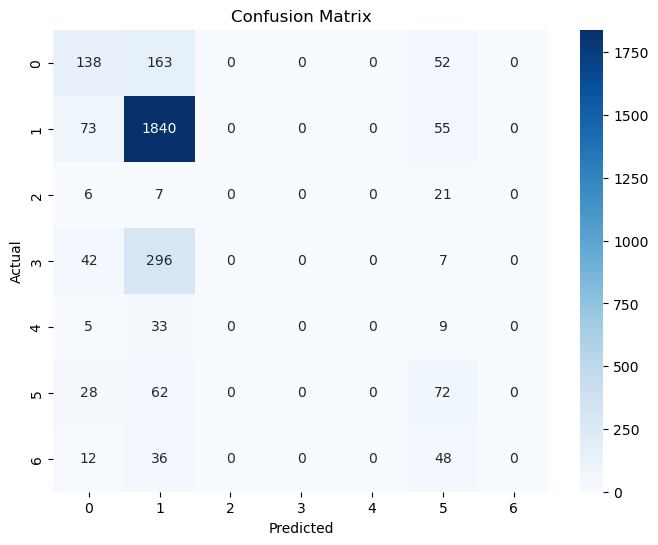

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [29]:
# plt.figure(figsize=(8,6))
# plt.plot(train_accuracies, label="Train Accuracy")
# plt.plot(val_accuracies, label="Validation Accuracy")
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")
# plt.title("Training and Validation Accuracy Curve")
# plt.legend()
# plt.grid()
# plt.show()

NameError: name 'train_accuracies' is not defined

<Figure size 800x600 with 0 Axes>

In [22]:

torch.save(model.state_dict(), "skin_cancer_model.pth")
print("Model saved!")


Model saved!
